In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier,plot_tree 
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,log_loss
from tqdm import tqdm
import os
os.chdir("/home/pgcp-ai/MachineLearning/Cases/Kyphosis/")

In [2]:
kyp = pd.read_csv("Kyphosis.csv")
kyp

,Kyphosis,Age,Number,Start
0,absent,71,3,5
1,absent,158,3,14
2,present,128,4,5
3,absent,2,5,1
4,absent,1,4,15
...,...,...,...,...
76,present,157,3,13
77,absent,26,7,13
78,absent,120,2,13
79,present,42,7,6


In [3]:
kyp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Kyphosis  81 non-null     object
 1   Age       81 non-null     int64 
 2   Number    81 non-null     int64 
 3   Start     81 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 2.7+ KB


In [4]:
kyp.isna().sum()

Kyphosis    0
Age         0
Number      0
Start       0
dtype: int64

In [5]:
X,y = kyp.drop("Kyphosis", axis = 1), kyp["Kyphosis"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state = 26, stratify = y)

In [6]:
dtc = DecisionTreeClassifier(criterion='gini')
dtc.fit(X_train, y_train)

DecisionTreeClassifier()

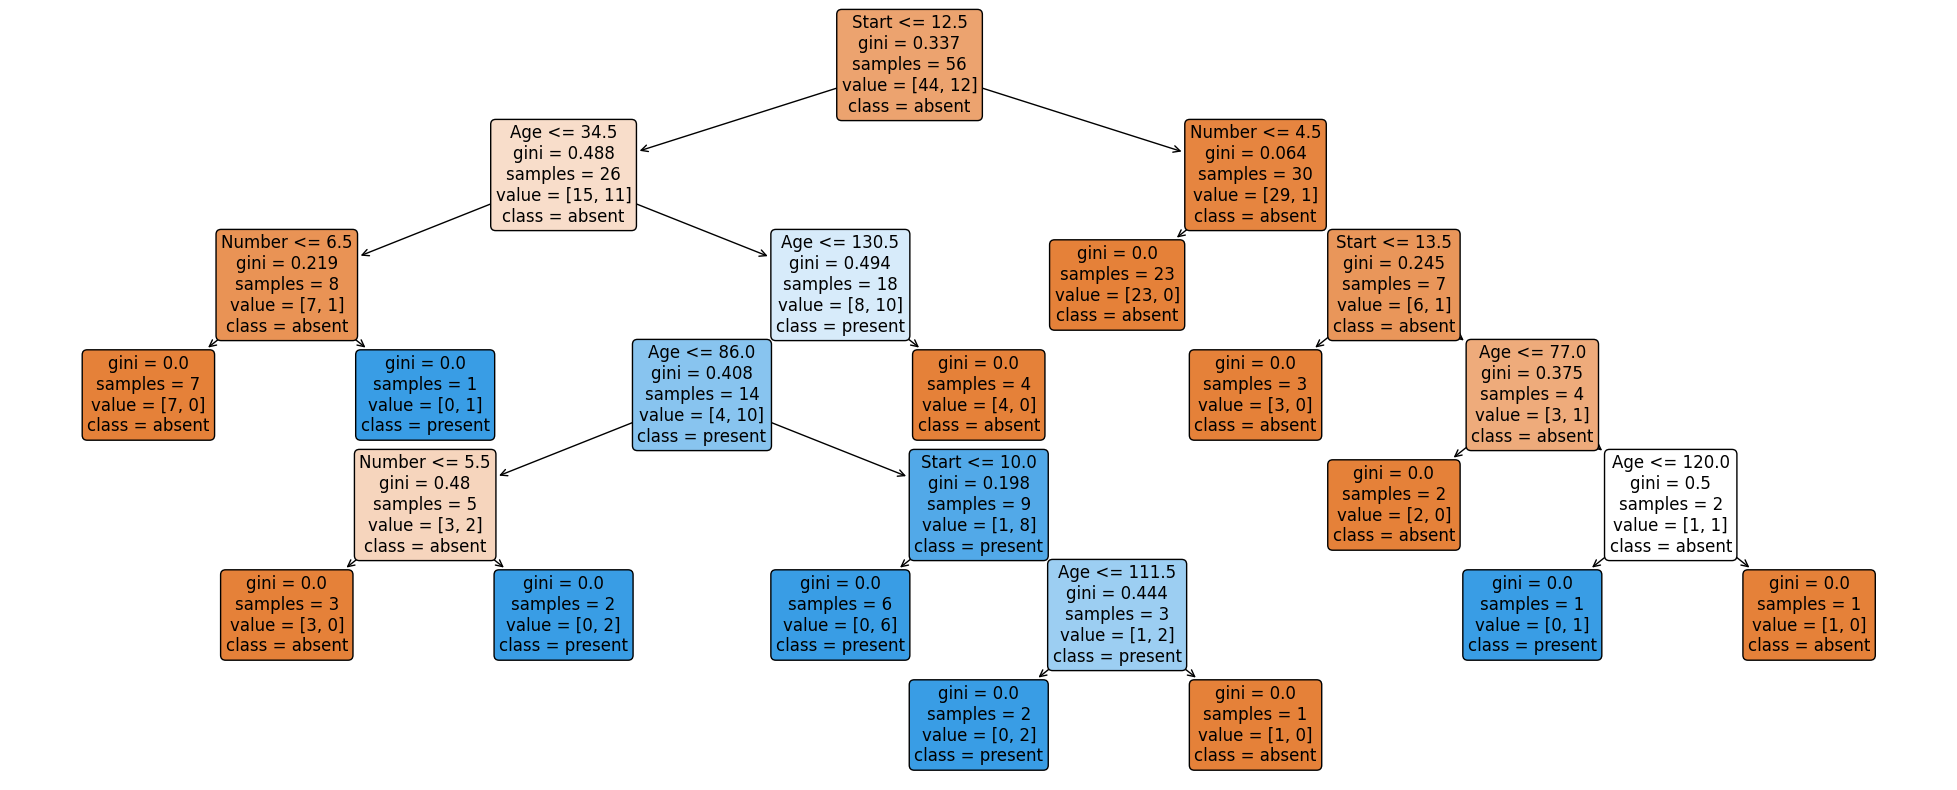

In [7]:
plt.figure(figsize = (25,10))
plot_tree(dtc,filled=True, rounded = True,feature_names=list(X.columns),class_names=['absent','present'],fontsize=12)
plt.show()

In [8]:
y_pred = dtc.predict(X_test)
y_pred_prob = dtc.predict_proba(X_test)

In [9]:
print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")
print(f"Log Loss: {log_loss(y_test,y_pred_prob)}")

Accuracy Score: 0.68
Log Loss: 11.533969084517489


In [10]:
depths = [1,2,3,4,5,6]
splits = []
scores = []
for d in tqdm(depths):
    dtc = DecisionTreeClassifier(criterion='gini',max_depth=d,random_state=26)
    dtc.fit(X_train, y_train)
    y_pred_prob = dtc.predict_proba(X_test)
    y_pred = dtc.predict(X_test)
    scores.append([d,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|████████████████████████████████████████████| 6/6 [00:00<00:00, 109.07it/s]


,Depth,Log Loss,Accuracy
0,1,0.404030,0.80
1,2,1.668450,0.84
2,3,4.525502,0.76
3,4,4.582748,0.76
5,6,11.533969,0.68
4,5,11.577914,0.64


In [11]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeClassifier(criterion='gini',min_samples_split=s,random_state=26)
    dtc.fit(X_train, y_train)
    y_pred_prob = dtc.predict_proba(X_test)
    y_pred = dtc.predict(X_test)
    scores.append([s,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Samples in each Node","Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|████████████████████████████████████████████| 5/5 [00:00<00:00, 135.18it/s]


,Min Samples in each Node,Log Loss,Accuracy
3,20,1.668450,0.84
4,30,1.714052,0.80
2,10,4.562643,0.76
1,5,8.717436,0.72
0,2,11.533969,0.68


In [12]:
depths = [1,2,3,4,5,6]
splits = [2,5,10,20,30]
scores = []
for s in tqdm(splits):
    for d in depths:
        dtc = DecisionTreeClassifier(criterion='gini',min_samples_split=s,random_state=26,max_depth=d)
        dtc.fit(X_train, y_train)
        y_pred_prob = dtc.predict_proba(X_test)
        y_pred = dtc.predict(X_test)
        scores.append([d,s,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node","Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|█████████████████████████████████████████████| 5/5 [00:00<00:00, 23.35it/s]


,Depth,Min Samples in each Node,Log Loss,Accuracy
0,1,2,0.404030,0.80
24,1,30,0.404030,0.80
6,1,5,0.404030,0.80
12,1,10,0.404030,0.80
18,1,20,0.404030,0.80
1,2,2,1.668450,0.84
7,2,5,1.668450,0.84
23,6,20,1.668450,0.84
22,5,20,1.668450,0.84
21,4,20,1.668450,0.84


  0%|                                                     | 0/5 [00:00<?, ?it/s]

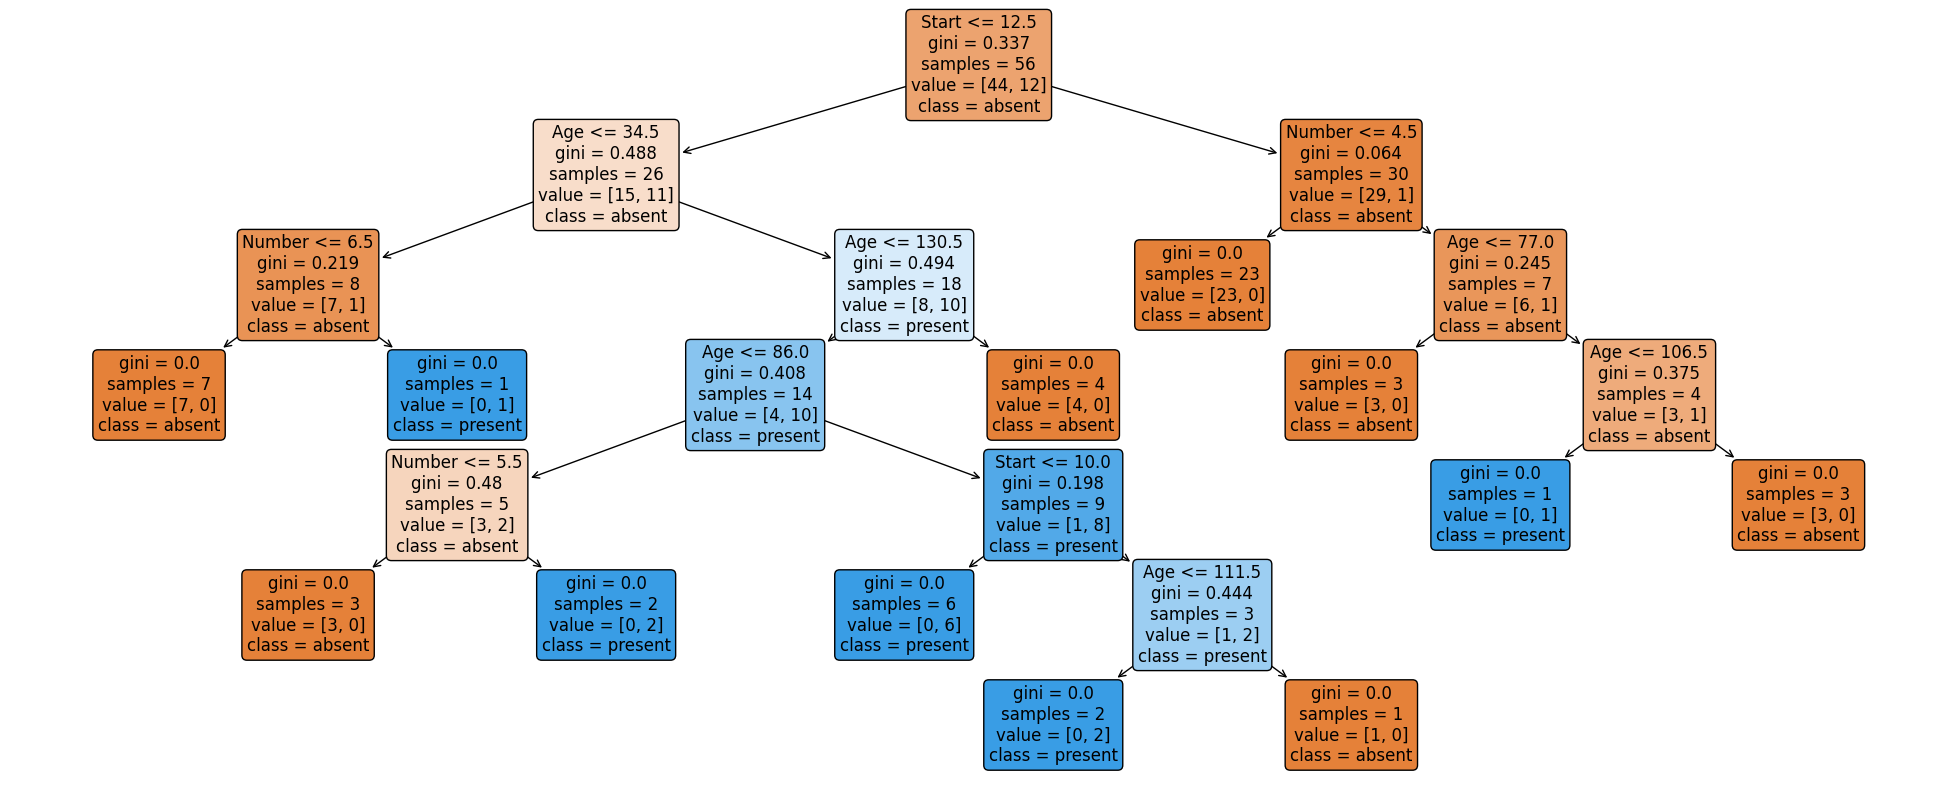

 20%|█████████                                    | 1/5 [00:00<00:03,  1.21it/s]

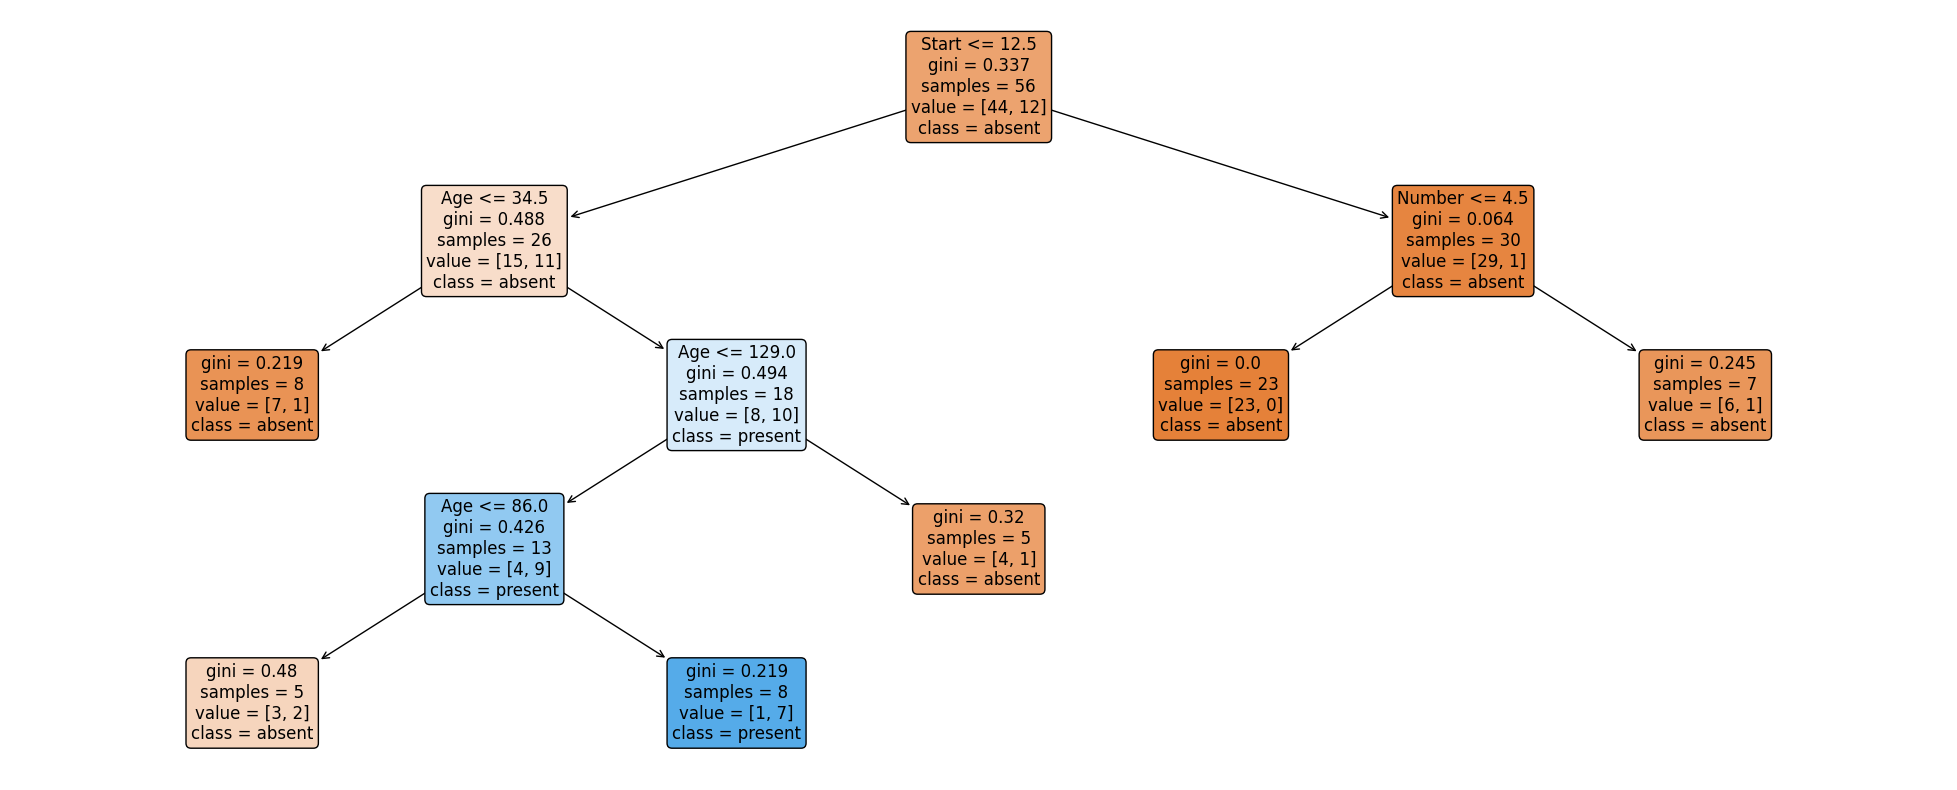

 40%|██████████████████                           | 2/5 [00:01<00:01,  1.64it/s]

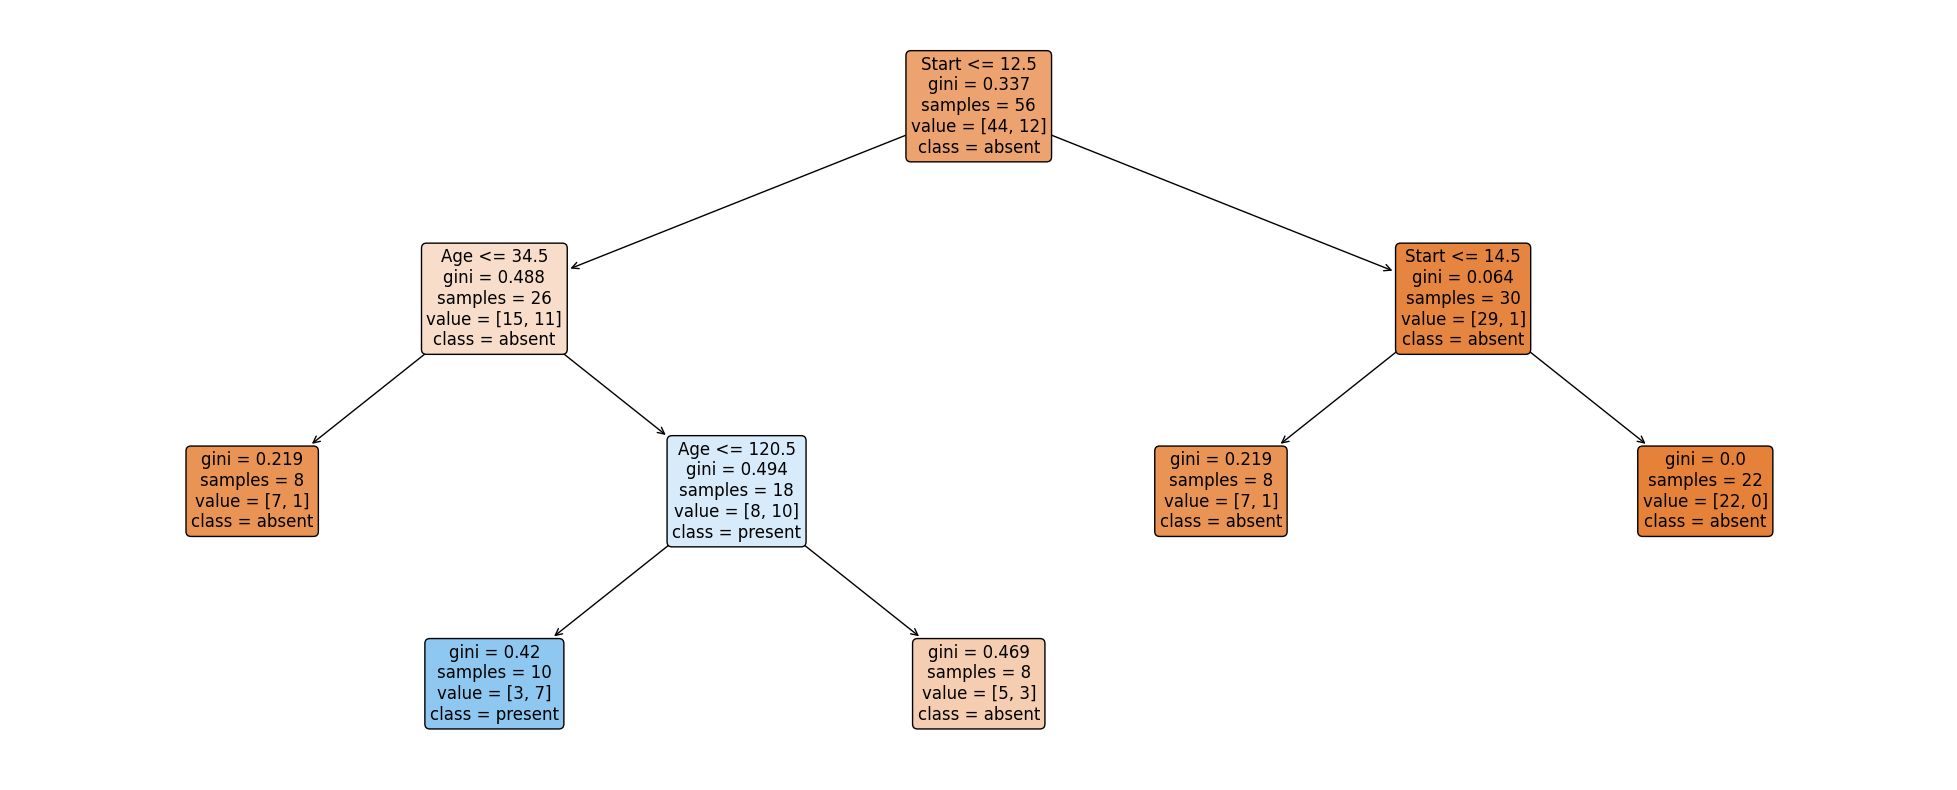

 60%|███████████████████████████                  | 3/5 [00:01<00:01,  1.99it/s]

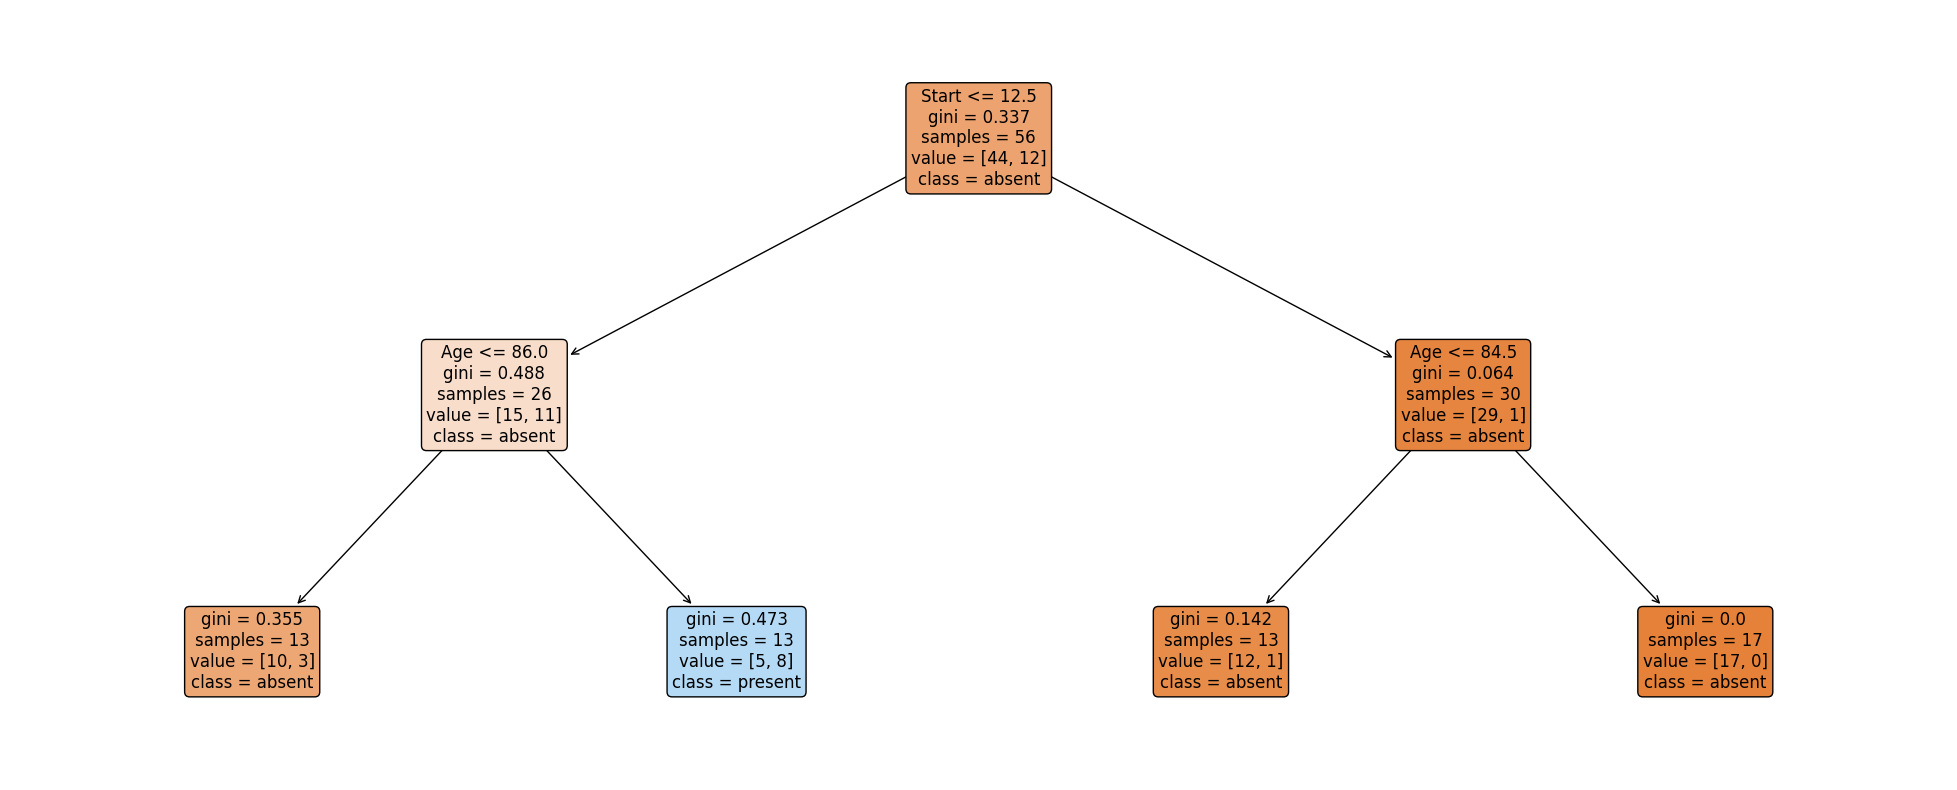

 80%|████████████████████████████████████         | 4/5 [00:01<00:00,  2.31it/s]

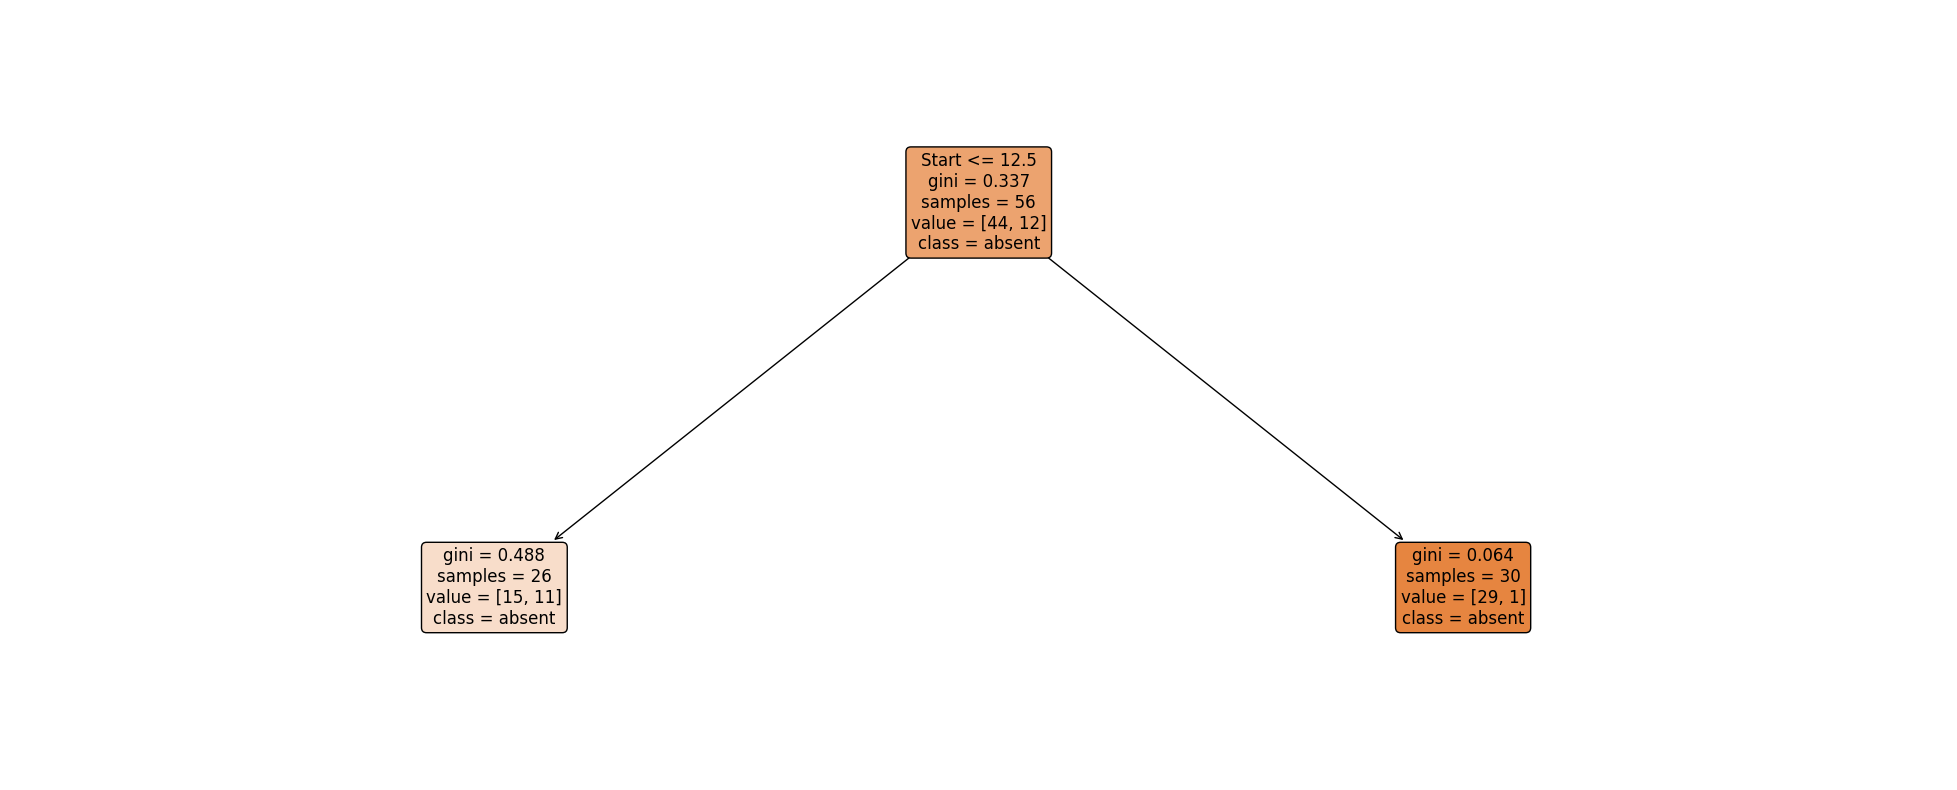

100%|█████████████████████████████████████████████| 5/5 [00:02<00:00,  2.27it/s]


,Min Leaves in each Node,Log Loss,Accuracy
2,8,0.358709,0.80
4,20,0.404030,0.80
3,10,1.703706,0.84
1,5,1.803195,0.76
0,1,11.533969,0.68


In [13]:
depths = [1,2,3,4,5,6]
splits = [1,5,8,10,20]
scores = []
for s in tqdm(splits):
    dtc = DecisionTreeClassifier(criterion='gini',min_samples_leaf=s,random_state=26)
    dtc.fit(X_train, y_train)
    plt.figure(figsize = (25,10))
    plot_tree(dtc,filled=True, rounded = True,feature_names=list(X.columns),class_names=['absent','present'],fontsize=12)
    plt.show()
    y_pred_prob = dtc.predict_proba(X_test)
    y_pred = dtc.predict(X_test)
    scores.append([s,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
    
df_scores = pd.DataFrame(scores,columns=["Min Leaves in each Node","Log Loss","Accuracy"])
df_scores.sort_values(['Log Loss', 'Accuracy'], ascending = [True, False])

In [14]:
depths = np.arange(1,7)
splits = np.arange(2,25)
leaves = np.arange(1,25)
scores = []
for d in tqdm(depths):
    for s in splits:
        for l in leaves:     
            dtc = DecisionTreeClassifier(criterion='gini',min_samples_split=s,random_state=26,max_depth=d,min_samples_leaf=l)
            dtc.fit(X_train, y_train)
            y_pred_prob = dtc.predict_proba(X_test)
            y_pred = dtc.predict(X_test)
            scores.append([d,s,l,log_loss(y_test,y_pred_prob),accuracy_score(y_test,y_pred)])
df_scores = pd.DataFrame(scores,columns=["Depth","Min Samples in each Node to Split",'Min Samples in each Leaf Node',"Log Loss","Accuracy"])
df_scores.sort_values('Log Loss')

100%|█████████████████████████████████████████████| 6/6 [00:16<00:00,  2.79s/it]


,Depth,Min Samples in each Node to Split,Min Samples in each Leaf Node,Log Loss,Accuracy
991,2,20,8,0.327948,0.84
1543,3,20,8,0.327948,0.84
751,2,10,8,0.327948,0.84
2695,5,22,8,0.327948,0.84
1519,3,19,8,0.327948,0.84
...,...,...,...,...,...
2232,5,3,1,8.749873,0.72
2809,6,4,2,8.749873,0.72
2760,6,2,1,11.533969,0.68
2784,6,3,1,11.533969,0.68


In [37]:
bm = DecisionTreeClassifier(random_state=26, max_depth = 3, min_samples_split=20, min_samples_leaf=8)
bm.fit(X, y)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=8, min_samples_split=20,
                       random_state=26)

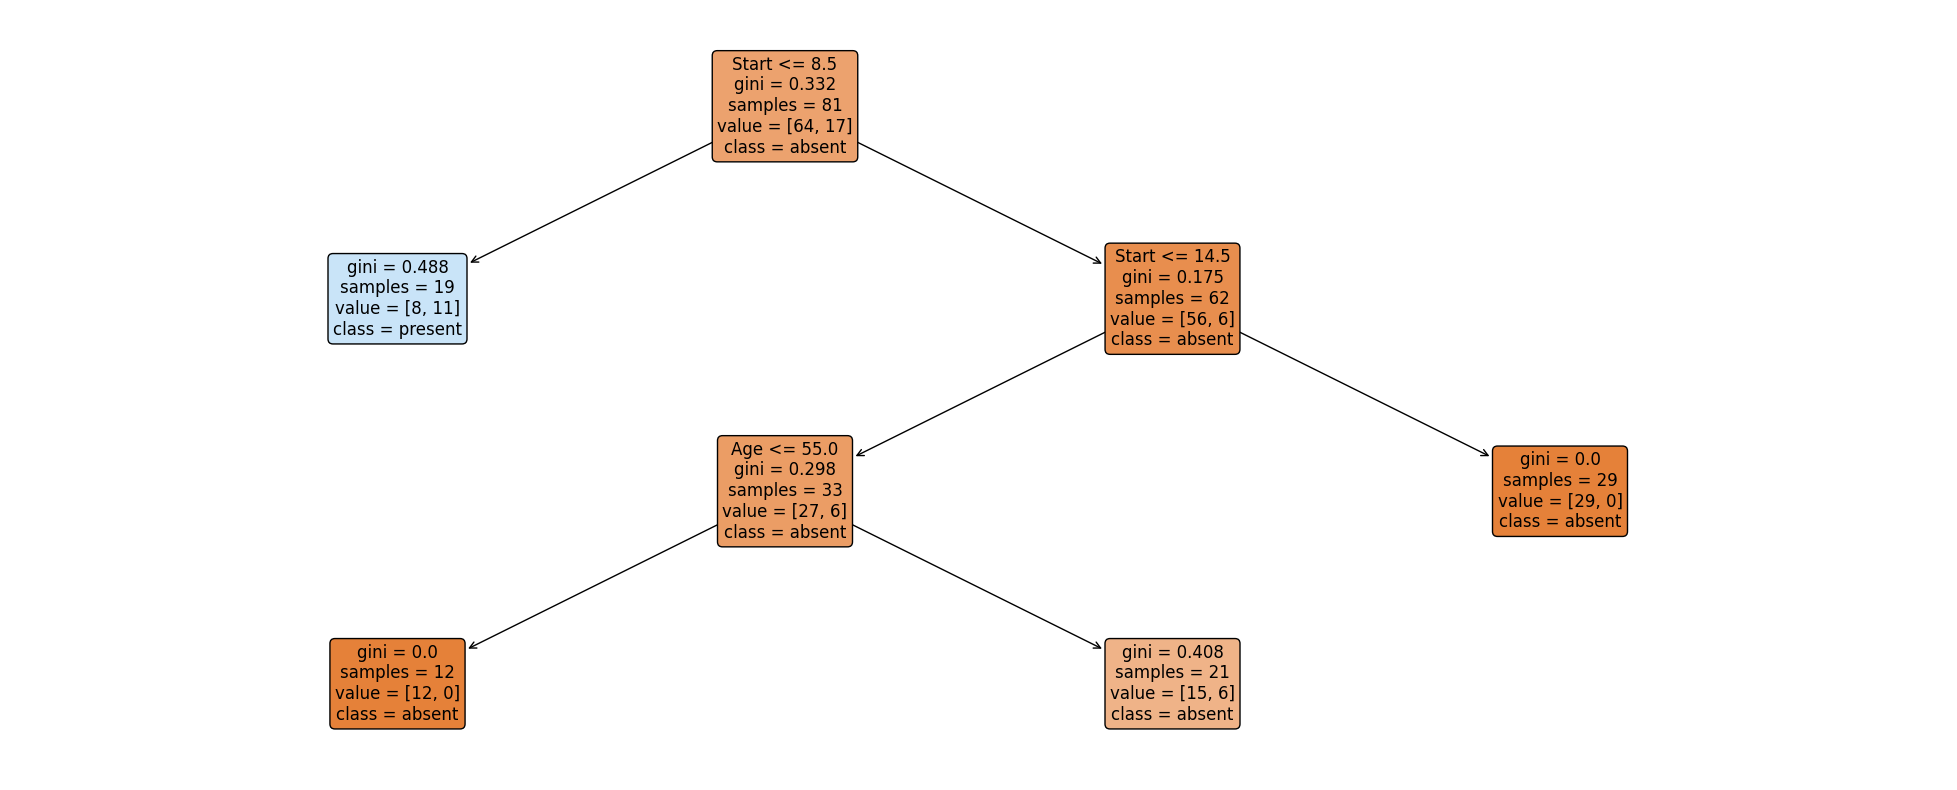

In [38]:
plt.figure(figsize = (25,10))
plot_tree(bm,filled=True, rounded = True,feature_names=list(X.columns),class_names=['absent','present'],fontsize=12)
plt.show()

In [39]:
bm.feature_importances_

array([0.13807386, 0.        , 0.86192614])

In [40]:
df_imp = pd.DataFrame({'feature':X.columns, 'Importance': bm.feature_importances_})
df_imp

,feature,Importance
0,Age,0.138074
1,Number,0.000000
2,Start,0.861926


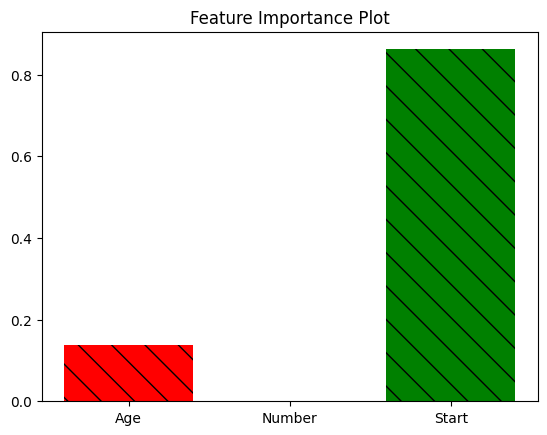

In [61]:
hatches = {'/', '\\', '|'}
plt.bar(df_imp['feature'], df_imp['Importance'],color=['red','orange','green'],hatch=hatches.pop())
plt.title('Feature Importance Plot')
plt.show()